# CAE Selected Feature Analysis

Simple combined notebook for two analyses:

1. **Duplicate features**: average number of distinct selected features per dataset and method.
2. **Stability**: average pairwise Jaccard similarity within supervised and unsupervised runs.

In [1]:
from pathlib import Path
import ast
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, kendalltau

# --- User settings ---
# Change this path if needed.
RESULTS_PATH = Path("../results/raw_results.csv")

# If the path above does not exist, this notebook also tries common fallback names.
FALLBACK_PATHS = [
    Path("../results.csv")]


In [2]:
def find_results_path(path: Path, fallbacks: list[Path]) -> Path:
    if path.exists():
        return path
    for candidate in fallbacks:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the results file. Set RESULTS_PATH to your CSV/TXT file."
    )

path = find_results_path(RESULTS_PATH, FALLBACK_PATHS)
print(f"Loading: {path}")

df = pd.read_csv(path)

required = {"dataset", "seed", "indices", "subset"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df.head()


Loading: ../results/raw_results.csv


,dataset,seed,k,indices,subset,reconstruction_mse,accuracy,balanced_accuracy,macro_f1
0,fashion_mnist,0,50,"[654, 204, 317, 651, 516, 535, 518, 42, 470, 9...",unsupervised_cae,0.019204,0.796929,0.796929,0.796109
1,fashion_mnist,0,50,"[14, 442, 582, 277, 315, 574, 585, 249, 38, 21...",supervised_cae,0.022619,0.804071,0.804071,0.802954
2,fashion_mnist,1,50,"[357, 274, 564, 46, 686, 525, 417, 535, 608, 7...",unsupervised_cae,0.019877,0.798857,0.798857,0.797310
3,fashion_mnist,1,50,"[92, 649, 746, 207, 191, 231, 355, 417, 608, 4...",supervised_cae,0.022372,0.803429,0.803429,0.801523
4,fashion_mnist,2,50,"[14, 202, 524, 709, 127, 455, 606, 712, 38, 53...",unsupervised_cae,0.019137,0.795500,0.795500,0.792837


## 1. Duplicate feature analysis

For each run, we count how many **distinct** features were selected after removing duplicates. If the CAE selects the same feature multiple times, the number of distinct features is smaller than `k`.


In [3]:
def parse_indices(value):
    # Parse the string/list in the indices column into a list of ints.
    if isinstance(value, list):
        return [int(x) for x in value]
    if pd.isna(value):
        return []
    parsed = ast.literal_eval(str(value))
    return [int(x) for x in parsed]

# Parse selected features and create unique feature sets.
df = df.copy()
df["indices_list"] = df["indices"].apply(parse_indices)
df["indices_set"] = df["indices_list"].apply(lambda xs: set(xs))
df["n_selected_total"] = df["indices_list"].apply(len)
df["n_selected_distinct"] = df["indices_set"].apply(len)
df["n_duplicates"] = df["n_selected_total"] - df["n_selected_distinct"]
df["method"] = df["subset"].replace({
    "supervised_cae": "Supervised",
    "unsupervised_cae": "Unsupervised",
})

df[["dataset", "seed", "method", "n_selected_total", "n_selected_distinct", "n_duplicates"]].head()


,dataset,seed,method,n_selected_total,n_selected_distinct,n_duplicates
0,fashion_mnist,0,Unsupervised,50,50,0
1,fashion_mnist,0,Supervised,50,45,5
2,fashion_mnist,1,Unsupervised,50,50,0
3,fashion_mnist,1,Supervised,50,46,4
4,fashion_mnist,2,Unsupervised,50,50,0


In [4]:
distinct_summary = (
    df.groupby(["dataset", "method"], as_index=False)
      .agg(
          distinct_mean=("n_selected_distinct", "mean"),
          distinct_std=("n_selected_distinct", "std"),
          duplicates_mean=("n_duplicates", "mean"),
          duplicates_std=("n_duplicates", "std"),
          runs=("seed", "count"),
      )
)

distinct_summary


,dataset,method,distinct_mean,distinct_std,duplicates_mean,duplicates_std,runs
0,activity,Supervised,17.40,2.137387,32.60,2.137387,20
1,activity,Unsupervised,34.35,2.455391,15.65,2.455391,20
2,coil20,Supervised,19.95,1.877148,30.05,1.877148,20
3,coil20,Unsupervised,14.85,1.954078,35.15,1.954078,20
4,fashion_mnist,Supervised,46.15,1.565248,3.85,1.565248,20
5,fashion_mnist,Unsupervised,49.90,0.307794,0.10,0.307794,20
6,isolet,Supervised,39.75,1.585294,10.25,1.585294,20
7,isolet,Unsupervised,43.85,2.183069,6.15,2.183069,20
8,mice_protein,Supervised,9.30,0.864505,0.70,0.864505,20
9,mice_protein,Unsupervised,9.15,0.875094,0.85,0.875094,20


In [5]:
from scipy.stats import wilcoxon, ttest_rel
import pandas as pd

print("=== n_selected_distinct ===")

for dataset in sorted(df["dataset"].unique()):

    sub = df[df["dataset"] == dataset]

    paired = sub.pivot_table(
        index="seed",
        columns="method",
        values="n_selected_distinct"
    )

    # Falls die Methoden anders heißen:
    # print(paired.columns)

    unsup_col = [c for c in paired.columns if "unsuper" in str(c).lower()][0]
    sup_col   = [c for c in paired.columns if "super" in str(c).lower()
                 and "unsuper" not in str(c).lower()][0]

    diff = paired[sup_col] - paired[unsup_col]

    w_stat, w_p = wilcoxon(
        paired[sup_col],
        paired[unsup_col]
    )

    t_stat, t_p = ttest_rel(
        paired[sup_col],
        paired[unsup_col]
    )

    cohens_d = diff.mean() / diff.std(ddof=1)

    print(f"\n{dataset}")
    print("-" * len(dataset))
    print(f"Unsupervised mean : {paired[unsup_col].mean():.2f}")
    print(f"Supervised mean   : {paired[sup_col].mean():.2f}")
    print(f"Mean difference   : {diff.mean():.2f}")
    print(f"Cohen's d         : {cohens_d:.3f}")
    print(f"Wilcoxon p        : {w_p:.6f}")
    print(f"Paired t-test p   : {t_p:.6f}")

=== n_selected_distinct ===

activity
--------
Unsupervised mean : 34.35
Supervised mean   : 17.40
Mean difference   : -16.95
Cohen's d         : -4.862
Wilcoxon p        : 0.000086
Paired t-test p   : 0.000000

coil20
------
Unsupervised mean : 14.85
Supervised mean   : 19.95
Mean difference   : 5.10
Cohen's d         : 1.542
Wilcoxon p        : 0.000151
Paired t-test p   : 0.000001

fashion_mnist
-------------
Unsupervised mean : 49.90
Supervised mean   : 46.15
Mean difference   : -3.75
Cohen's d         : -2.417
Wilcoxon p        : 0.000119
Paired t-test p   : 0.000000

isolet
------
Unsupervised mean : 43.85
Supervised mean   : 39.75
Mean difference   : -4.10
Cohen's d         : -1.423
Wilcoxon p        : 0.000178
Paired t-test p   : 0.000004

mice_protein
------------
Unsupervised mean : 9.15
Supervised mean   : 9.30
Mean difference   : 0.15
Cohen's d         : 0.122
Wilcoxon p        : 0.580257
Paired t-test p   : 0.590583

mnist
-----
Unsupervised mean : 49.95
Supervised mean   

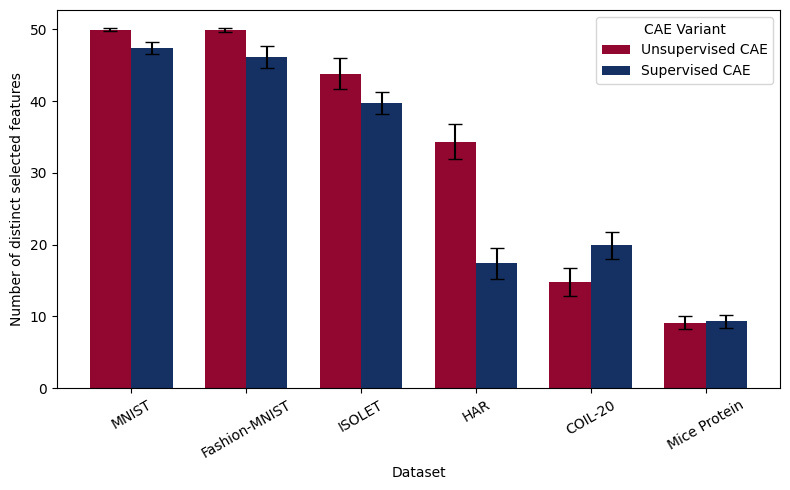

In [6]:
def plot_grouped_bar(summary, value_col, std_col, title, ylabel, filename):
    dataset_order = [
        "mnist",
        "fashion_mnist",
        "isolet",
        "activity",
        "coil20",
        "mice_protein",
    ]

    dataset_labels = {
        "mnist": "MNIST",
        "fashion_mnist": "Fashion-MNIST",
        "isolet": "ISOLET",
        "activity": "HAR",
        "coil20": "COIL-20",
        "mice_protein": "Mice Protein",
    }

    methods = ["unsupervised_cae", "supervised_cae"]

    palette = {
        "unsupervised_cae": "#910730",
        "supervised_cae": "#153163",
    }

    label_map = {
        "unsupervised_cae": "Unsupervised CAE",
        "supervised_cae": "Supervised CAE",
    }

    summary_plot = summary.copy()

    summary_plot["method"] = summary_plot["method"].replace({
        "Unsupervised": "unsupervised_cae",
        "Supervised": "supervised_cae",
        "unsupervised": "unsupervised_cae",
        "supervised": "supervised_cae",
    })

    x = np.arange(len(dataset_order))
    width = 0.36

    fig, ax = plt.subplots(figsize=(8, 5))

    for offset, method in zip([-width / 2, width / 2], methods):
        sub = (
            summary_plot
            .set_index(["dataset", "method"])
            .reindex(
                pd.MultiIndex.from_product(
                    [dataset_order, [method]],
                    names=["dataset", "method"],
                )
            )
            .reset_index()
        )

        ax.bar(
            x + offset,
            sub[value_col].values,
            width,
            yerr=sub[std_col].values,
            capsize=5,
            color=palette[method],
            label=label_map[method],
        )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Dataset")
    ax.set_xticks(x)
    ax.set_xticklabels(
        [dataset_labels[d] for d in dataset_order],
        rotation=30,
    )
    ax.legend(title="CAE Variant")

    fig.tight_layout()
    plt.show()


plot_grouped_bar(
    distinct_summary,
    value_col="distinct_mean",
    std_col="distinct_std",
    title="",
    ylabel="Number of distinct selected features",
    filename="distinct_selected_features.png",
)


## 2. Stability analysis

Stability is measured as the average **pairwise Jaccard similarity** between selected feature sets from different seeds within the same method.



In [7]:
import itertools
import numpy as np
import pandas as pd

def jaccard(a, b):
    if len(a) == 0 and len(b) == 0:
        return np.nan
    return len(a & b) / len(a | b)


def pairwise_jaccards(feature_sets):
    return np.asarray([
        jaccard(a, b)
        for a, b in itertools.combinations(feature_sets, 2)
    ])


rng = np.random.default_rng(42)

significance_rows = []

for dataset, group_dataset in df.groupby("dataset"):

    supervised = {}
    unsupervised = {}

    for _, row in group_dataset.iterrows():
        method = row["method"]

        if "unsuper" in method.lower():
            unsupervised[row["seed"]] = row["indices_set"]
        else:
            supervised[row["seed"]] = row["indices_set"]

    common_seeds = sorted(set(supervised.keys()) & set(unsupervised.keys()))

    supervised_sets = [supervised[s] for s in common_seeds]
    unsupervised_sets = [unsupervised[s] for s in common_seeds]

    supervised_pairwise = pairwise_jaccards(supervised_sets)
    unsupervised_pairwise = pairwise_jaccards(unsupervised_sets)

    supervised_mean = np.mean(supervised_pairwise)
    supervised_std = np.std(supervised_pairwise, ddof=1)

    unsupervised_mean = np.mean(unsupervised_pairwise)
    unsupervised_std = np.std(unsupervised_pairwise, ddof=1)

    observed_diff = supervised_mean - unsupervised_mean

    n_perm = 10000
    perm_diffs = np.zeros(n_perm)

    for p in range(n_perm):
        perm_sup = []
        perm_unsup = []

        for seed in common_seeds:
            sup_set = supervised[seed]
            unsup_set = unsupervised[seed]

            if rng.random() < 0.5:
                perm_sup.append(sup_set)
                perm_unsup.append(unsup_set)
            else:
                perm_sup.append(unsup_set)
                perm_unsup.append(sup_set)

        perm_diffs[p] = (
            np.mean(pairwise_jaccards(perm_sup))
            - np.mean(pairwise_jaccards(perm_unsup))
        )

    permutation_p = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

    significance_rows.append({
        "dataset": dataset,

        "supervised_mean": supervised_mean,
        "supervised_std": supervised_std,

        "unsupervised_mean": unsupervised_mean,
        "unsupervised_std": unsupervised_std,

        "mean_difference": observed_diff,
        "permutation_p": permutation_p,

        "n_seeds": len(common_seeds),
        "n_pairwise_comparisons": len(supervised_pairwise),
    })

stability_significance = pd.DataFrame(significance_rows)

stability_significance

,dataset,supervised_mean,supervised_std,unsupervised_mean,unsupervised_std,mean_difference,permutation_p,n_seeds,n_pairwise_comparisons
0,activity,0.552016,0.093773,0.277749,0.045238,0.274266,0.0000,20,190
1,coil20,0.630766,0.078548,0.419916,0.096617,0.210851,0.0000,20,190
2,fashion_mnist,0.219567,0.040175,0.069221,0.024977,0.150346,0.0000,20,190
3,isolet,0.190168,0.043960,0.118119,0.032746,0.072049,0.0000,20,190
4,mice_protein,0.078417,0.062382,0.097988,0.072195,-0.019572,0.0458,20,190
5,mnist,0.194434,0.043483,0.105435,0.035279,0.088999,0.0000,20,190


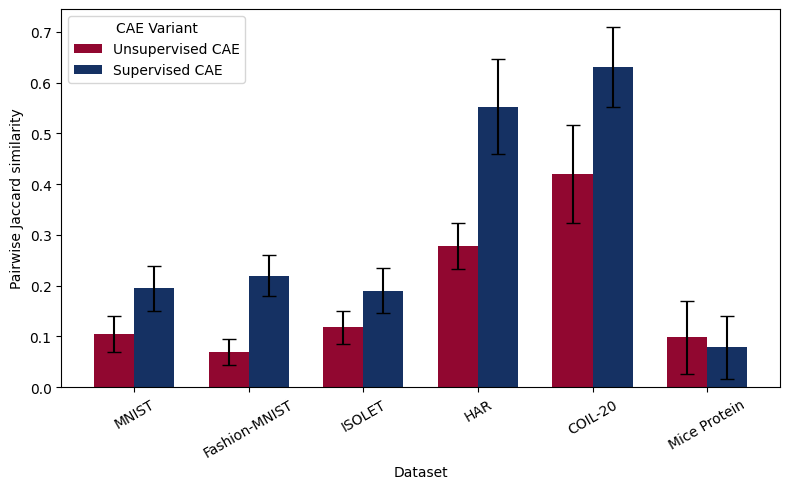

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

dataset_order = [
    "mnist",
    "fashion_mnist",
    "isolet",
    "activity",
    "coil20",
    "mice_protein",
]

dataset_labels = {
    "mnist": "MNIST",
    "fashion_mnist": "Fashion-MNIST",
    "isolet": "ISOLET",
    "activity": "HAR",
    "coil20": "COIL-20",
    "mice_protein": "Mice Protein",
}

palette = {
    "Unsupervised": "#910730",
    "Supervised": "#153163",
}

label_map = {
    "Unsupervised": "Unsupervised CAE",
    "Supervised": "Supervised CAE",
}

df_plot = stability_significance.copy()
df_plot = df_plot.set_index("dataset").reindex(dataset_order)

x = np.arange(len(dataset_order))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width / 2,
    df_plot["unsupervised_mean"].values,
    width=width,
    yerr=df_plot["unsupervised_std"].values,
    capsize=5,
    color=palette["Unsupervised"],
    label=label_map["Unsupervised"],
)

ax.bar(
    x + width / 2,
    df_plot["supervised_mean"].values,
    width=width,
    yerr=df_plot["supervised_std"].values,
    capsize=5,
    color=palette["Supervised"],
    label=label_map["Supervised"],
)

ax.set_xticks(x)
ax.set_xticklabels(
    [dataset_labels[d] for d in dataset_order],
    rotation=30,
)

ax.set_ylabel("Pairwise Jaccard similarity")
ax.set_xlabel("Dataset")
ax.legend(title="CAE Variant")

plt.tight_layout()
plt.show()